In [1]:
## Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")
%matplotlib inline

In [2]:
df = pd.read_csv(r"C:\Users\ANKIT\Downloads\Travel.csv")
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


## Data Cleaning

###  Handle Missing Value

 1) Handle Missing Value
 2) Handle Duplicates
 3) Check Data Type
 4) Understand the Dataset

In [3]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [4]:
### Checking all the categories
df['Gender'].value_counts()

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64

In [5]:
df['TypeofContact'].value_counts()

TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: count, dtype: int64

In [6]:
df['MaritalStatus'].value_counts()

MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64

In [7]:
df['Gender'] = df['Gender'].replace('Fe Male','Female')

In [8]:
df['MaritalStatus'] = df['MaritalStatus'].replace('Single','Unmarried')

In [9]:
df.tail()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
4883,204883,1,49.0,Self Enquiry,3,9.0,Small Business,Male,3,5.0,Deluxe,4.0,Unmarried,2.0,1,1,1,1.0,Manager,26576.0
4884,204884,1,28.0,Company Invited,1,31.0,Salaried,Male,4,5.0,Basic,3.0,Unmarried,3.0,1,3,1,2.0,Executive,21212.0
4885,204885,1,52.0,Self Enquiry,3,17.0,Salaried,Female,4,4.0,Standard,4.0,Married,7.0,0,1,1,3.0,Senior Manager,31820.0
4886,204886,1,19.0,Self Enquiry,3,16.0,Small Business,Male,3,4.0,Basic,3.0,Unmarried,3.0,0,5,0,2.0,Executive,20289.0
4887,204887,1,36.0,Self Enquiry,1,14.0,Salaried,Male,4,4.0,Basic,4.0,Unmarried,3.0,1,3,1,2.0,Executive,24041.0


## Checking the Missing Value

In [10]:
### These are the features with nan

feature_with_nan = [features for features in df.columns if df[features].isnull().sum() >= 1]
for feature in feature_with_nan:
    print(feature , np.round(df[feature].isnull().mean()*100,5),'% missing value')

Age 4.62357 % missing value
TypeofContact 0.51146 % missing value
DurationOfPitch 5.13502 % missing value
NumberOfFollowups 0.92062 % missing value
PreferredPropertyStar 0.53191 % missing value
NumberOfTrips 2.86416 % missing value
NumberOfChildrenVisiting 1.35025 % missing value
MonthlyIncome 4.76678 % missing value


In [11]:
### Stastics on numerical columns(Null Cols)
df[feature_with_nan].select_dtypes(exclude = 'object').describe()

,Age,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
count,4662.000000,4637.000000,4843.000000,4862.000000,4748.000000,4822.000000,4655.000000
mean,37.622265,15.490835,3.708445,3.581037,3.236521,1.187267,23619.853491
std,9.316387,8.519643,1.002509,0.798009,1.849019,0.857861,5380.698361
min,18.000000,5.000000,1.000000,3.000000,1.000000,0.000000,1000.000000
25%,31.000000,9.000000,3.000000,3.000000,2.000000,1.000000,20346.000000
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000
75%,44.000000,20.000000,4.000000,4.000000,4.000000,2.000000,25571.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,3.000000,98678.000000


## Imputing NULL Values
1) Impute Median Value for Age Column
2) Impute Mode for Type of Contract
3) Impute Median for DurationOfPitch
4) Impute Mode for NumberOfFollowups as it is Discrete Fetaure
5) Impute Mode for PreferredPropertyStar
6) Impute Median for NumberOfTrips
7) Impute Mode for NumberOfChildrenVisiting
8) Impute Median for MonthlyIncome

In [12]:
## Age
df.Age.fillna(df.Age.median(),inplace = True)

## TypeofContract
df.TypeofContact.fillna(df.TypeofContact.mode()[0],inplace = True)

## DurationOfPitch
df.DurationOfPitch.fillna(df.DurationOfPitch.median(),inplace = True)

## NumberOfFollowups
df.NumberOfFollowups.fillna(df.NumberOfFollowups.mode()[0],inplace = True)

## PreferredPropertyStar
df.PreferredPropertyStar.fillna(df.PreferredPropertyStar.mode()[0],inplace = True)

## NumberOfTrips
df.NumberOfTrips.fillna(df.NumberOfTrips.median(),inplace = True)

## NumberOfChildrenVisiting
df.NumberOfChildrenVisiting.fillna(df.NumberOfChildrenVisiting.mode()[0],inplace = True)

## MonthlyIncome
df.MonthlyIncome.fillna(df.MonthlyIncome.median(),inplace = True)

In [13]:
df.isnull().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [14]:
df.drop('CustomerID' , inplace = True , axis = 1)

In [15]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


## Feature Engineering

### Feature Extraction

In [16]:
df['TotalVisiting'] = df['NumberOfPersonVisiting'] + df['NumberOfChildrenVisiting']
df = df.drop(columns = ['NumberOfPersonVisiting','NumberOfChildrenVisiting'])

In [17]:
### Get all the Numerical Feature
num_feature = [feature for feature in df.columns if df[feature].dtype !='O']
print("Number of Numerical Feature are : ",len(num_feature))

Number of Numerical Feature are :  12


In [18]:
## Get all the Categoricsl Feature
cat_feature = [feature for feature in df.columns if df[feature].dtype =='O']
print("Number of Categoricsl Feature are : ",len(cat_feature))

Number of Categoricsl Feature are :  6


In [19]:
## Discrete Feature
discrete_feature = [feature for feature in num_feature if len(df[feature].unique()) <= 25]
print("Number of Discrete Feature are : ",len(discrete_feature))

Number of Discrete Feature are :  9


In [20]:
## Continuous Feature
cont_feature = [feature for feature in num_feature if feature not in discrete_feature]
print("Number of Continuous Feature are : ",len(cont_feature))

Number of Continuous Feature are :  3


## Train Test Split and Model Training

In [21]:
from sklearn.model_selection import train_test_split
X = df.drop(['ProdTaken'],axis = 1)
y = df['ProdTaken']

In [22]:
y.value_counts()

ProdTaken
0    3968
1     920
Name: count, dtype: int64

In [23]:
X.head()

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [24]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3, random_state = 10)
X_train.shape,X_test.shape

((3421, 17), (1467, 17))

In [25]:
## Create colmn Transformer with 3 types of transformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

cat_features = X.select_dtypes(include='object').columns
num_features = X.select_dtypes(exclude='object').columns
 
numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')
 
preprocessor = ColumnTransformer([
    ('OneHotEncoder', oh_transformer, cat_features),
    ('StandardScaler', numeric_transformer, num_features)
])

In [26]:
print(preprocessor)

ColumnTransformer(transformers=[('OneHotEncoder',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 Index(['TypeofContact', 'Occupation', 'Gender', 'ProductPitched',
       'MaritalStatus', 'Designation'],
      dtype='object')),
                                ('StandardScaler', StandardScaler(),
                                 Index(['Age', 'CityTier', 'DurationOfPitch', 'NumberOfFollowups',
       'PreferredPropertyStar', 'NumberOfTrips', 'Passport',
       'PitchSatisfactionScore', 'OwnCar', 'MonthlyIncome', 'TotalVisiting'],
      dtype='object'))])


In [27]:
X_train_processed = preprocessor.fit_transform(X_train)   
X_test_processed  = preprocessor.transform(X_test) 

In [28]:
X_train_processed

array([[ 1.        ,  0.        ,  1.        , ..., -1.28447803,
         1.12077211, -0.79365988],
       [ 1.        ,  0.        ,  0.        , ..., -1.28447803,
        -0.11138261,  0.62193472],
       [ 1.        ,  0.        ,  1.        , ..., -1.28447803,
         0.73194429, -0.08586258],
       ...,
       [ 1.        ,  0.        ,  0.        , ..., -1.28447803,
        -0.22519996, -0.79365988],
       [ 0.        ,  0.        ,  0.        , ..., -1.28447803,
        -0.48480367,  0.62193472],
       [ 0.        ,  0.        ,  1.        , ...,  0.77852636,
        -1.14093858,  0.62193472]], shape=(3421, 26))

In [29]:
X_test_processed

array([[ 1.        ,  0.        ,  0.        , ...,  0.77852636,
        -1.10454013, -1.50145718],
       [ 1.        ,  0.        ,  0.        , ...,  0.77852636,
        -0.04782977, -1.50145718],
       [ 1.        ,  0.        ,  1.        , ...,  0.77852636,
         0.28283757, -1.50145718],
       ...,
       [ 1.        ,  0.        ,  1.        , ...,  0.77852636,
         2.7544652 ,  0.62193472],
       [ 0.        ,  0.        ,  0.        , ...,  0.77852636,
        -0.41046611, -0.08586258],
       [ 1.        ,  0.        ,  0.        , ...,  0.77852636,
        -0.50695087,  0.62193472]], shape=(1467, 26))

## Random Forest Classifier

In [49]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix,precision_score,recall_score,f1_score,roc_auc_score

In [50]:
models = {
    'Random Forest': RandomForestClassifier(),
    'Decision Tree' : DecisionTreeClassifier()
}

for i in range (len(list(models))):
    
    model = list(models.values())[i]
    model.fit(X_train_processed,y_train) ## train the model

    ## Make Prediction
    y_train_pred = model.predict(X_train_processed)
    y_test_pred = model.predict(X_test_processed)

    ## Training Set Performance
    model_training_accuracy = accuracy_score(y_train,y_train_pred)
    model_train_f1 = f1_score(y_train,y_train_pred,average = 'weighted')
    model_train_precision = precision_score(y_train,y_train_pred)
    model_train_recall = recall_score(y_train,y_train_pred)
    model_train_rocauc_score = roc_auc_score(y_train,y_train_pred)

    ## Test Set Performance
    model_test_accuracy = accuracy_score(y_test,y_test_pred)
    model_test_f1 = f1_score(y_test,y_test_pred,average = 'weighted')
    model_test_precision = precision_score(y_test,y_test_pred)
    model_test_recall = recall_score(y_test,y_test_pred)
    model_test_rocauc_score = roc_auc_score(y_test,y_test_pred)

    print(list(models.keys())[i])

    print('Model Performance for Training Set')
    print('- Accuracy :{:.4f}'.format(model_training_accuracy))
    print('- F1 score :{:.4f}'.format(model_train_f1))
    print('- Precision :{:.4f}'.format(model_train_precision))
    print('- Recall :{:.4f}'.format(model_train_recall))
    print('- ROC and AUC :{:.4f}'.format(model_train_rocauc_score))


    print('-------------------------------------------------------------------')


    

    print('Model Performance for Test Set')
    print('- Accuracy :{:.4f}'.format(model_test_accuracy))
    print('- F1 score :{:.4f}'.format(model_test_f1))
    print('- Precision :{:.4f}'.format(model_test_precision))
    print('- Recall :{:.4f}'.format(model_test_recall))
    print('- ROC and AUC :{:.4f}'.format(model_test_rocauc_score))

    print('='*68)
    print('\n')
    

Random Forest
Model Performance for Training Set
- Accuracy :1.0000
- F1 score :1.0000
- Precision :1.0000
- Recall :1.0000
- ROC and AUC :1.0000
-------------------------------------------------------------------
Model Performance for Test Set
- Accuracy :0.9359
- F1 score :0.9312
- Precision :0.9419
- Recall :0.6585
- ROC and AUC :0.8252


Decision Tree
Model Performance for Training Set
- Accuracy :1.0000
- F1 score :1.0000
- Precision :1.0000
- Recall :1.0000
- ROC and AUC :1.0000
-------------------------------------------------------------------
Model Performance for Test Set
- Accuracy :0.9012
- F1 score :0.9022
- Precision :0.6950
- Recall :0.7317
- ROC and AUC :0.8335




## Hyperparameter Tuning for Random Forest

In [55]:
rf_params = {
    'n_estimators'      : [100,200,500,1000],
    'max_features'      : ['sqrt', 'log2'],
    'max_depth'         : [5,8,15,None,10],
    'min_samples_split' : [2, 5, 10, 15, 20],
    'min_samples_leaf'  : [1, 2, 4, 6, 8],
    'bootstrap'         : [True, False],
    'criterion'         : ['gini', 'entropy']
}

In [56]:
rf_params

{'n_estimators': [100, 200, 500, 1000],
 'max_features': ['sqrt', 'log2'],
 'max_depth': [5, 8, 15, None, 10],
 'min_samples_split': [2, 5, 10, 15, 20],
 'min_samples_leaf': [1, 2, 4, 6, 8],
 'bootstrap': [True, False],
 'criterion': ['gini', 'entropy']}

In [57]:
## Model List
randomcv_models = [
    ('RF',RandomForestClassifier(),rf_params)
]

In [63]:
from sklearn.model_selection import RandomizedSearchCV
model_param = {}
for name,model,params in randomcv_models:
    random = RandomizedSearchCV(estimator = model,
                               param_distributions = params,
                               n_iter = 100,
                               cv = 3,
                               verbose = 2,
                               n_jobs = -1)

    random.fit(X_train_processed,y_train)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f'------------------Best Param for {model_name}------------------------')
    print(model_param[model_name])

Fitting 3 folds for each of 100 candidates, totalling 300 fits
------------------Best Param for RF------------------------
{'n_estimators': 1000, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 15, 'criterion': 'entropy', 'bootstrap': False}


In [66]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators= 1000, 
                                            min_samples_split = 2, 
                                            min_samples_leaf = 1, 
                                            max_features = 'log2',
                                            max_depth = 15,
                                            criterion = 'entropy',
                                            bootstrap = False
                                           )
}

for i in range (len(list(models))):
    
    model = list(models.values())[i]
    model.fit(X_train_processed,y_train) ## train the model

    ## Make Prediction
    y_train_pred = model.predict(X_train_processed)
    y_test_pred = model.predict(X_test_processed)

    ## Training Set Performance
    model_training_accuracy = accuracy_score(y_train,y_train_pred)
    model_train_f1 = f1_score(y_train,y_train_pred,average = 'weighted')
    model_train_precision = precision_score(y_train,y_train_pred)
    model_train_recall = recall_score(y_train,y_train_pred)
    model_train_rocauc_score = roc_auc_score(y_train,y_train_pred)

    ## Test Set Performance
    model_test_accuracy = accuracy_score(y_test,y_test_pred)
    model_test_f1 = f1_score(y_test,y_test_pred,average = 'weighted')
    model_test_precision = precision_score(y_test,y_test_pred)
    model_test_recall = recall_score(y_test,y_test_pred)
    model_test_rocauc_score = roc_auc_score(y_test,y_test_pred)

    print(list(models.keys())[i])

    print('Model Performance for Training Set')
    print('- Accuracy :{:.4f}'.format(model_training_accuracy))
    print('- F1 score :{:.4f}'.format(model_train_f1))
    print('- Precision :{:.4f}'.format(model_train_precision))
    print('- Recall :{:.4f}'.format(model_train_recall))
    print('- ROC and AUC :{:.4f}'.format(model_train_rocauc_score))


    print('-------------------------------------------------------------------')


    

    print('Model Performance for Test Set')
    print('- Accuracy :{:.4f}'.format(model_test_accuracy))
    print('- F1 score :{:.4f}'.format(model_test_f1))
    print('- Precision :{:.4f}'.format(model_test_precision))
    print('- Recall :{:.4f}'.format(model_test_recall))
    print('- ROC and AUC :{:.4f}'.format(model_test_rocauc_score))

    print('='*68)
    print('\n')
    

Random Forest
Model Performance for Training Set
- Accuracy :0.9991
- F1 score :0.9991
- Precision :1.0000
- Recall :0.9955
- ROC and AUC :0.9978
-------------------------------------------------------------------
Model Performance for Test Set
- Accuracy :0.9434
- F1 score :0.9402
- Precision :0.9358
- Recall :0.7114
- ROC and AUC :0.8508




## Plot ROC and AUC Curve

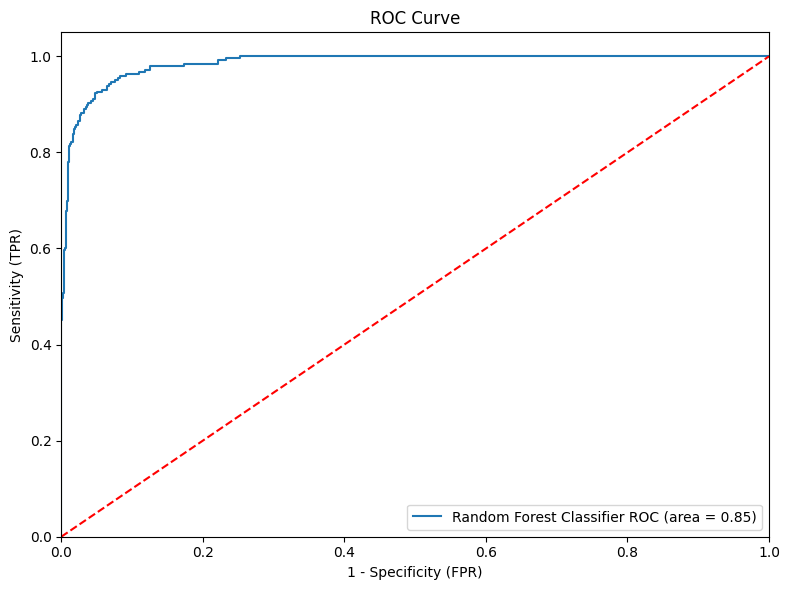

In [71]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

auc_models = [
    {
        'label': 'Random Forest Classifier',
        'model': RandomForestClassifier(
                     n_estimators      = 1000,
                     min_samples_split = 2,
                     min_samples_leaf  = 1,
                     max_features      = 'log2',
                     max_depth         = 15,
                     criterion         = 'entropy',
                     bootstrap         = False
                 ),
        'auc': 0.8508
    },
]

plt.figure(figsize=(8, 6))

for algo in auc_models:
    model = algo['model']
    model.fit(X_train_processed, y_train)                         

    fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test_processed)[:, 1])

    plt.plot(fpr, tpr, label='%s ROC (area = %0.2f)' % (algo['label'], algo['auc']))  

plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1 - Specificity (FPR)')
plt.ylabel('Sensitivity (TPR)')                                  
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()